In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [38]:
df=pd.read_csv("economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [39]:
# drop no need column
df.drop(columns=["Unnamed: 0","year","month"], axis=1, inplace=True)

In [40]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [41]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

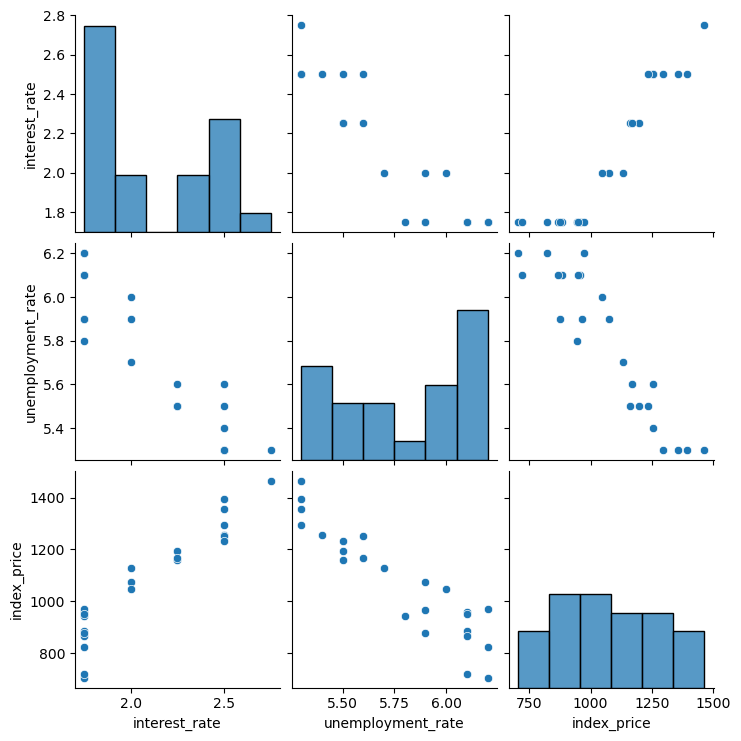

In [42]:
import seaborn as sns

sns.pairplot(df)

In [43]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0.5, 0, 'interest rate')

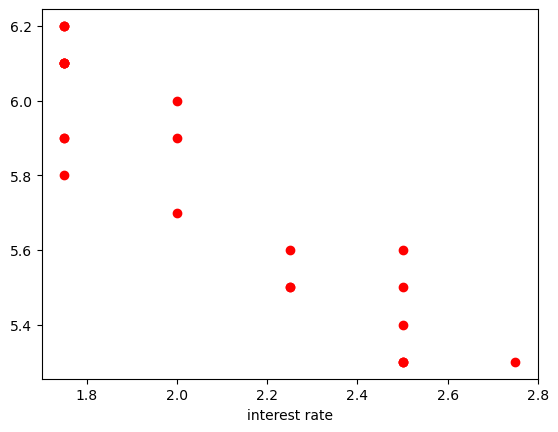

In [44]:
plt.scatter(df['interest_rate'],df['unemployment_rate'], color='r')
plt.xlabel("interest rate")

In [45]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [46]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [47]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.25, random_state=20)

<Axes: xlabel='interest_rate', ylabel='index_price'>

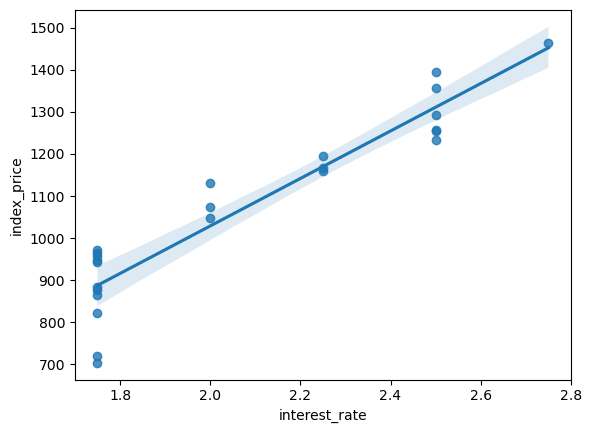

In [49]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

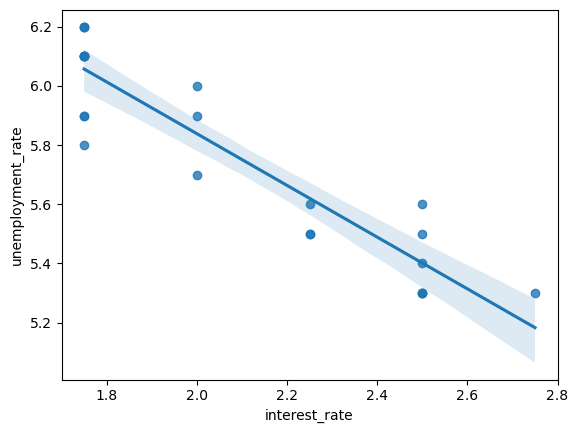

In [50]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain) 
xtest = scaler.transform(xtest)     

In [54]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(xtrain,ytrain)

LinearRegression()

In [55]:
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(lr, xtrain, ytrain, scoring='neg_mean_squared_error', cv=3 )

In [57]:
cvs

array([-15063.67112483,  -2697.34566338,  -3477.38416238])

In [58]:
np.mean(cvs)

-7079.46698352924

In [59]:
ypred = lr.predict(xtest)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(ytest, ypred)
mae = mean_absolute_error(ytest,ypred)
rmse = np.sqrt(mse)

In [62]:
print(mse, mae, rmse)

2742.6700637433246 46.86593151479974 52.37050757576562


In [64]:
from sklearn.metrics import r2_score
score = r2_score(ytest,ypred)
score

0.937584787704871

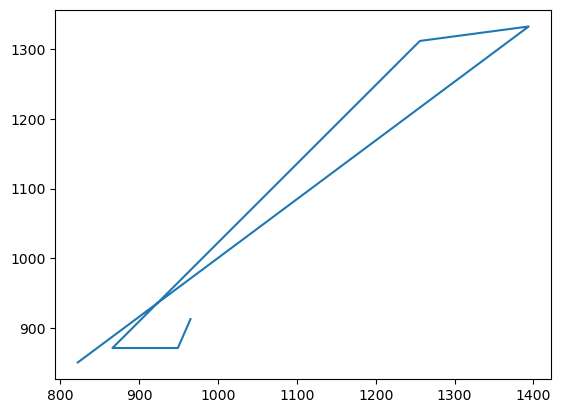

In [66]:
plt.plot(ytest,ypred)

In [67]:
residuals = ytest-ypred
residuals

13    51.968079
17    77.370284
19    -5.629716
4    -55.401045
1     61.897853
21   -28.928613
Name: index_price, dtype: float64

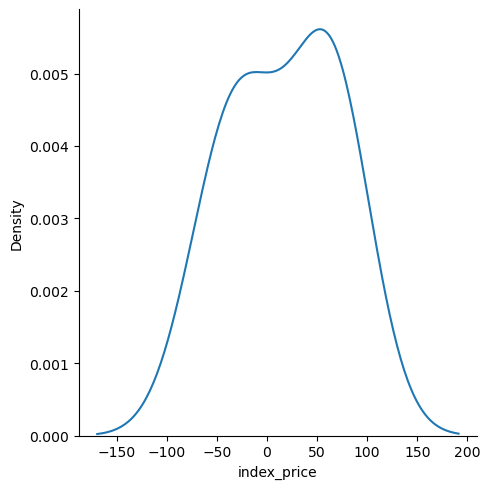

In [68]:
sns.displot(residuals, kind='kde')